# Table of Contents
1. [Introduction](#Introduction)
2. [Data Loading & EDA](#Data-Loading-EDA)
3. [Segmentation](#Segmentation)


# 1. Introduction
<a id="Introduction"></a>

We have access to the [obfuscated data from GA4](https://developers.google.com/analytics/bigquery/web-ecommerce-demo-dataset) that shows user engagement with the Google Merchandise Store site. Our task is to segment users based on our observations into four segments: New, Active, Dormant and Lost. 

* A customer is considered as **lost** after a period of 60 days after a purchase without re-purchase. That's the only definition we have - the rest we will define in the course of action.

In [14]:
# Suppress warnings for Git
import warnings
warnings.filterwarnings('ignore')

# 2. Data Loading
<a id="Data-Loading_EDA"></a>

In [15]:
# Import table from Google Cloud
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client()

# Take just one day of data for exploration
df = client.query("""
    SELECT *
    FROM `sandbox-2-472920.ga4_obfuscated_sample_ecommerce2.events_20210131`
    ;
"""
).to_dataframe()


In [16]:
# Some columns are nested lists which is not very human readable
cols_to_expand = ["event_params", "privacy_info", "items", "user_ltv", "device", "geo", "traffic_source", "ecommerce"]

for col in cols_to_expand:
    if col in df.columns:
        expanded = pd.json_normalize(df[col]).add_prefix(f"{col}.")
        df = df.drop(columns=[col]).join(expanded)


In [17]:
df.head()

,event_date,event_timestamp,event_name,event_previous_timestamp,event_value_in_usd,event_bundle_sequence_id,event_server_timestamp_offset,user_id,user_pseudo_id,user_properties,...,ecommerce.purchase_revenue_in_usd,ecommerce.purchase_revenue,ecommerce.refund_value_in_usd,ecommerce.refund_value,ecommerce.shipping_value_in_usd,ecommerce.shipping_value,ecommerce.tax_value_in_usd,ecommerce.tax_value,ecommerce.unique_items,ecommerce.transaction_id
0,20210131,1612069510766593,page_view,<NA>,NaN,6595101026,<NA>,None,1026454.4271112504,[],...,NaN,None,None,None,None,None,None,None,NaN,None
1,20210131,1612069529243877,scroll,<NA>,NaN,9011338476,<NA>,None,1026454.4271112504,[],...,NaN,None,None,None,None,None,None,None,NaN,None
2,20210131,1612069515781635,page_view,<NA>,NaN,-6830522854,<NA>,None,1026454.4271112504,[],...,NaN,None,None,None,None,None,None,None,NaN,None
3,20210131,1612069530073506,user_engagement,<NA>,NaN,-8264942910,<NA>,None,1026454.4271112504,[],...,NaN,None,None,None,None,None,None,None,NaN,None
4,20210131,1612069510766593,session_start,<NA>,NaN,6595101026,<NA>,None,1026454.4271112504,[],...,NaN,None,None,None,None,None,None,None,NaN,None


In [18]:
# Using DuckDB for EDA
import duckdb

# Check Event types
print(duckdb.query('SELECT event_name, COUNT(*) FROM df GROUP BY 1 ORDER BY 2 DESC'))


┌─────────────────────┬──────────────┐
│     event_name      │ count_star() │
│       varchar       │    int64     │
├─────────────────────┼──────────────┤
│ page_view           │         9498 │
│ user_engagement     │         5005 │
│ scroll              │         2870 │
│ session_start       │         2760 │
│ first_visit         │         2127 │
│ view_item           │         1829 │
│ view_promotion      │         1190 │
│ add_to_cart         │          295 │
│ select_item         │          237 │
│ begin_checkout      │          234 │
│ view_search_results │          198 │
│ add_shipping_info   │          100 │
│ select_promotion    │           71 │
│ add_payment_info    │           53 │
│ purchase            │           19 │
│ click               │            3 │
├─────────────────────┴──────────────┤
│ 16 rows                  2 columns │
└────────────────────────────────────┘



In [19]:
# Check source / medium
print(duckdb.query('SELECT DISTINCT "traffic_source.name", "traffic_source.medium", "traffic_source.source", COUNT(*) FROM df GROUP BY 1,2,3 ORDER BY 4 DESC'))

┌─────────────────────┬───────────────────────┬─────────────────────────────────┬──────────────┐
│ traffic_source.name │ traffic_source.medium │      traffic_source.source      │ count_star() │
│       varchar       │        varchar        │             varchar             │    int64     │
├─────────────────────┼───────────────────────┼─────────────────────────────────┼──────────────┤
│ (organic)           │ organic               │ google                          │         7899 │
│ (direct)            │ (none)                │ (direct)                        │         7064 │
│ <Other>             │ <Other>               │ <Other>                         │         3709 │
│ (referral)          │ referral              │ <Other>                         │         2219 │
│ (referral)          │ referral              │ shop.googlemerchandisestore.com │         2149 │
│ (data deleted)      │ (data deleted)        │ (data deleted)                  │         1379 │
│ <Other>             │ cpc   

In [20]:
# Check traffic by device
print(duckdb.query('SELECT DISTINCT "device.category", COUNT(*) FROM df GROUP BY 1 ORDER BY 2 DESC'))

┌─────────────────┬──────────────┐
│ device.category │ count_star() │
│     varchar     │    int64     │
├─────────────────┼──────────────┤
│ desktop         │        15239 │
│ mobile          │        10624 │
│ tablet          │          626 │
└─────────────────┴──────────────┘



In [21]:
# Check purchase attributes
print(duckdb.query("""SELECT "ecommerce.unique_items", "ecommerce.transaction_id", "ecommerce.purchase_revenue_in_usd", "ecommerce.refund_value" FROM df WHERE event_name = 'purchase'"""))

┌────────────────────────┬──────────────────────────┬───────────────────────────────────┬────────────────────────┐
│ ecommerce.unique_items │ ecommerce.transaction_id │ ecommerce.purchase_revenue_in_usd │ ecommerce.refund_value │
│         double         │         varchar          │              double               │         int32          │
├────────────────────────┼──────────────────────────┼───────────────────────────────────┼────────────────────────┤
│                    1.0 │ (not set)                │                               0.0 │                   NULL │
│                    1.0 │ (not set)                │                               0.0 │                   NULL │
│                    1.0 │ (not set)                │                               0.0 │                   NULL │
│                    1.0 │ (not set)                │                               0.0 │                   NULL │
│                    1.0 │ (not set)                │                           

Main takeaways:
* We don't need to use all events, we could probably target generic ones like `page_view`, `purchase` + some others to segment users. This would make our queries faster and we will not have to scan large amounts of data.
* It would be interesting to look at source of traffic for users and break them down by device type.
* Something is funky with purchase event metadata but we will assume that purchase events correctly identify the successful purchase.

# 3. Segmentation
<a id="Segmentation"></a>

In [22]:
with open("sql/query1.sql", "r") as f:
    query1 = f.read()
    
segmentation1 = client.query(query1).to_dataframe()

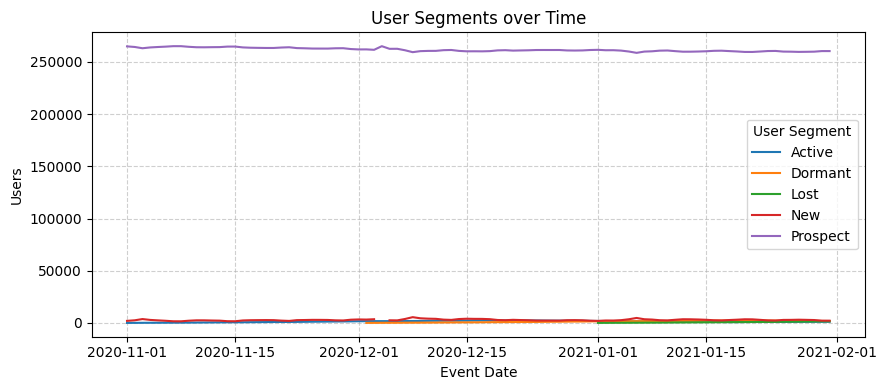

In [23]:
# Visuals
import pandas as pd
import matplotlib.pyplot as plt

segmentation1['event_date'] = pd.to_datetime(segmentation1['event_date'])

# Pivot the data so each user_segment is a column
pivot_df = segmentation1.pivot(index='event_date', columns='user_segment', values='users')

plt.figure(figsize=(9,4))
for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], label=col)

plt.title("User Segments over Time")
plt.xlabel("Event Date")
plt.ylabel("Users")
plt.legend(title="User Segment")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


The Prospect segment is too large, let's exclude them from analysis.

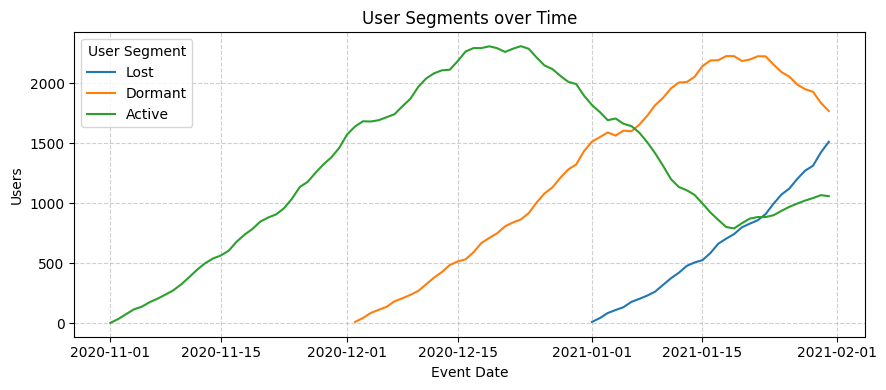

In [24]:
# Let's zoom in on specific segments that we would want to activate
zoom_in = pivot_df[['Lost', 'Dormant', 'Active']]

# Plot
plt.figure(figsize=(9,4))
for col in zoom_in.columns:
    plt.plot(zoom_in.index, zoom_in[col], label=col)

plt.title("User Segments over Time")
plt.xlabel("Event Date")
plt.ylabel("Users")
plt.legend(title="User Segment")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

* **Activation is fragile:** Users can become active, but many don’t stay there long — the volatility shows that active engagement is not stable.
* **Retention risk:** The slow but steady increase in Dormant users suggests a growing risk of churn if they aren’t reactivated.

In [25]:
with open("sql/query2.sql", "r") as f:
    query2 = f.read()
    
segmentation2 = client.query(query2).to_dataframe()

**Adding in a new segment: "Engaged Shopper"**
* These are users that engage with the site, click on items, put them in the cart but don't complete the purches.
* Very important users to activate - high probability to purchase.

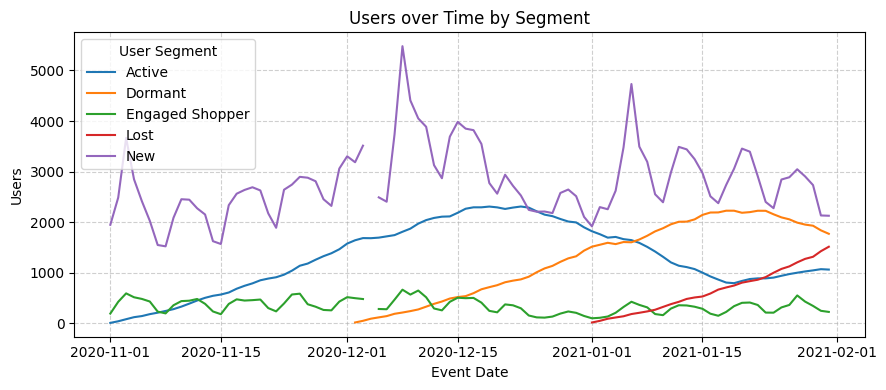

In [26]:
segmentation2['event_date'] = pd.to_datetime(segmentation2['event_date'])
pivot_df2 = segmentation2.pivot(index='event_date', columns='user_segment', values='users')
pivot_df2 = pivot_df2[['Active', 'Dormant', 'Engaged Shopper', 'Lost', 'New']]

plt.figure(figsize=(9,4))
for col in pivot_df2.columns:
    plt.plot(pivot_df2.index, pivot_df2[col], label=col)

plt.title("Users over Time by Segment")
plt.xlabel("Event Date")
plt.ylabel("Users")
plt.legend(title="User Segment")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()